# 11 — LSTM Forecasting (PyTorch)

Stage 4a, deep learning track. A single **global** model trained across every series in scope — in deliberate contrast with `10_arima_baseline.ipynb`'s per-series SARIMA fits — so it can share statistical strength across series instead of learning each one from scratch.

Windowing: for target day `t`, the input is the `LSTM_WINDOW` (28) days strictly *before* `t`. Evaluated the same way as SARIMA: every test-day prediction uses only true past history, never the model's own prior predictions — an apples-to-apples comparison with `10_arima_baseline.ipynb`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data.load import read_features
from src.forecasting.splits import time_split
from src.forecasting.evaluate import evaluate_forecasts, compute_scales
from src.forecasting.backtest import backtest_summary
from src.forecasting.lstm_model import (
    build_windows, fit_scalers, train_lstm, predict, save_scalers, feature_columns,
)

import mlflow

pd.set_option("display.max_columns", 50)

features = read_features()
train, val, test = time_split(features)
scales = compute_scales(train)


## Build sliding windows

Slices every scoped series into (past-28-days -> next-day-target) samples, assigning each sample to train/val/test by its *target* day's date.

In [2]:
samples, cols = build_windows(features, window=config.LSTM_WINDOW)
print(f"n_features={len(cols)}")
for split, s in samples.items():
    print(f"{split:5s}: {len(s)} windows")


n_features=51
train: 4900 windows
val  : 920 windows
test : 930 windows


## Per-series scaling

One `StandardScaler` per series for the input features and one for the target, each fit on that series' TRAIN windows only, then applied unchanged to its val/test windows.

In [3]:
scalers = fit_scalers(samples["train"])
print(f"fitted scalers for {len(scalers)} series")


fitted scalers for 10 series


## Train the global LSTM

2-layer LSTM (hidden 64 -> 32) + FC head, Adam optimizer, Huber loss (robust to demand spikes), early stopping on validation loss. Every run is logged to MLflow under experiment `forecasting_lstm`.

In [4]:
model, history, run_ctx = train_lstm(
    samples["train"], samples["val"], scalers,
    n_features=len(cols),
    hidden1=64, hidden2=32,
    lr=1e-3, batch_size=64,
    max_epochs=60, patience=8,
    log_to_mlflow=True,
)
print(f"trained {len(history['train_loss'])} epochs, best val_loss={min(history['val_loss']):.4f}")


2026/08/07 17:12:34 INFO mlflow.tracking.fluent: Experiment with name 'forecasting_lstm' does not exist. Creating a new experiment.


trained 9 epochs, best val_loss=0.4186


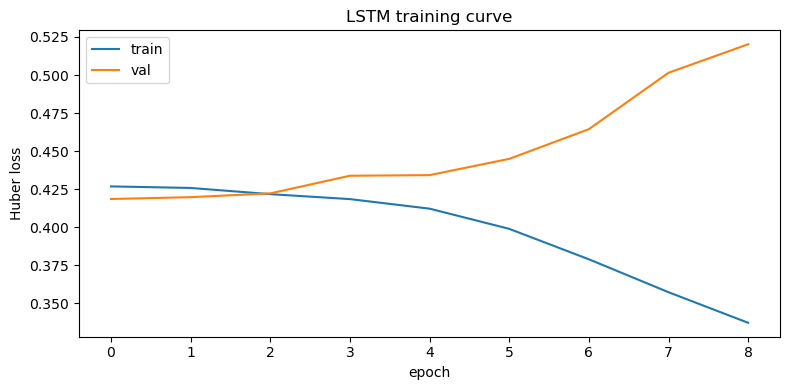

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history["train_loss"], label="train")
ax.plot(history["val_loss"], label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("Huber loss")
ax.set_title("LSTM training curve")
ax.legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "lstm_training_curve.png", dpi=120)
plt.show()


## Evaluate on the test window

In [6]:
lstm_forecasts = predict(model, samples["test"], scalers)
lstm_overall = evaluate_forecasts(lstm_forecasts, scales)["overall"]
lstm_overall


MAE                      89.027430
RMSE                    110.331457
sMAPE                    69.604235
MASE_macro                0.709259
MASE_volume_weighted      0.711931
dtype: float64

In [7]:
# log final test-set metrics to the same MLflow run, then close it
mlflow.log_metrics(
    {
        "test_MAE": lstm_overall["MAE"],
        "test_RMSE": lstm_overall["RMSE"],
        "test_sMAPE": lstm_overall["sMAPE"],
        "test_MASE_macro": lstm_overall["MASE_macro"],
    }
)
mlflow.end_run()


## Backtest robustness check

Same 2-origin chunking as the SARIMA notebook, for direct comparison.

In [8]:
backtest_summary(lstm_forecasts, scales, n_origins=2)


,origin,start_date,end_date,MAE,RMSE,sMAPE,MASE_macro
0,1,2023-10-01,2023-11-16,90.999368,113.284697,70.303349,0.725025
1,2,2023-11-17,2024-01-01,87.012624,107.230042,68.889922,0.693150


## Save outputs

In [9]:
config.FORECASTS_DIR.mkdir(parents=True, exist_ok=True)
lstm_forecasts.to_parquet(config.FORECASTS_DIR / "lstm_forecasts.parquet", index=False)
save_scalers(scalers)
print("saved lstm_forecasts.parquet, scalers, and models/lstm/lstm.pt (from train_lstm)")


saved lstm_forecasts.parquet, scalers, and models/lstm/lstm.pt (from train_lstm)


## Summary

- One global LSTM trained across all 10 scoped series, evaluated one-step-ahead on the same test window and the same MASE yardstick as `10_arima_baseline.ipynb`'s SARIMA.
- Training run (hyperparameters, per-epoch loss, final test metrics, checkpoint artifact) logged to MLflow under `forecasting_lstm`.
- Forecasts saved for the head-to-head comparison in `12_forecast_comparison.ipynb`.